In [15]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

import matplotlib.pyplot as plt
import networkx as nx

In [16]:
# Set random seed for reproducibility
np.random.seed(86273)

# Parameters
num_nodes = 8  # Number of nodes
edge_probability = 0.5  # Probability of an edge existing between any two nodes

# Generate random 2D coordinates for the nodes (for Euclidean distance calculation)
coordinates = np.random.rand(num_nodes, 2) * 100

# Create a random directed graph where each arc is only directed one way (either i->j or j->i, not both)
edges = []
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):  # Ensure we only consider one direction for each pair
        if np.random.rand() < edge_probability:
            if np.random.rand() < 0.5:  # Randomly choose direction
                edges.append((i, j))  # Directed edge from i to j
            else:
                edges.append((j, i))  # Directed edge from j to i

# Generate a random distance matrix based on distances between node coordinates
dist_matrix = np.zeros((num_nodes, num_nodes))
for i, j in edges:
    dist_matrix[i][j] = int(np.linalg.norm(coordinates[i] - coordinates[j]))

# Display the generated edges and distance matrix
print("Generated Directed Edges (no reverse arcs):", edges)
print("Generated Distance Matrix:", dist_matrix)


# Display generated edges and distances
# print("Generated Random Directed Edges:", edges)
# print("Generated Distance Matrix (random weights):", dist_matrix)

Generated Directed Edges (no reverse arcs): [(0, 1), (6, 0), (7, 0), (1, 4), (5, 1), (6, 1), (3, 2), (4, 2), (2, 5), (6, 2), (7, 2), (7, 3), (6, 4), (7, 4), (5, 7), (6, 7)]
Generated Distance Matrix: [[ 0. 53.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 41.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 47.  0.  0.]
 [ 0.  0. 30.  0.  0.  0.  0.  0.]
 [ 0.  0. 39.  0.  0.  0.  0.  0.]
 [ 0. 49.  0.  0.  0.  0.  0. 71.]
 [32. 78. 46.  0. 41.  0.  0. 49.]
 [36.  0. 38.  8. 69.  0.  0.  0.]]


In [17]:
# Create the model
m = gp.Model("Shortest_Path_LP")

# Decision variables: x_{ij} for each edge (i,j)
x = m.addVars(edges, vtype=GRB.BINARY, name="x")

# Objective: Minimize the total distance (sum of w_ij * x_ij)
m.setObjective(gp.quicksum(dist_matrix[i][j] * x[i, j] for i, j in edges), GRB.MINIMIZE)

# Flow conservation constraints
start_node = 0
end_node = num_nodes - 1

# Source node: exactly one outgoing flow
m.addConstr(gp.quicksum(x[start_node, j] for j in range(num_nodes) if (start_node, j) in edges) == 1, name="source_outflow")

# Target node: exactly one incoming flow
m.addConstr(gp.quicksum(x[i, end_node] for i in range(num_nodes) if (i, end_node) in edges) == 1, name="target_inflow")

# Flow balance for intermediate nodes: inflow = outflow
for i in range(num_nodes):
    if i != start_node and i != end_node:
        m.addConstr(
            gp.quicksum(x[i, j] for j in range(num_nodes) if (i, j) in edges) ==
            gp.quicksum(x[j, i] for j in range(num_nodes) if (j, i) in edges) ,
            name=f"flow_balance_{i}"
        )

# Optimize the model
m.optimize()

# Extract the solution (edges in the optimal path)
solution = [(i, j) for i, j in edges if x[i, j].x > 0.5]
print("Optimal Path:", solution)
print("Total Distance:", m.objVal)

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 8 rows, 16 columns and 26 nonzeros
Model fingerprint: 0x198c197f
Variable types: 0 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e+00, 8e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 251.0000000
Presolve removed 8 rows and 16 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 20 available processors)

Solution count 1: 251 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.510000000000e+02, best bound 2.510000000000e+02, gap 0.0000%
Optimal Path: [(0, 1), (1, 4), (4, 2), (2, 5), (5, 7)]
Total Dis

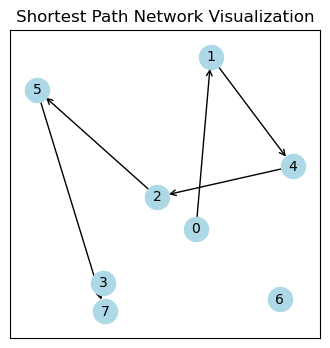

In [18]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes
for i in range(num_nodes):
    G.add_node(i, pos=coordinates[i])

# Add edges based on the solution
for edge in solution:
    G.add_edge(edge[0], edge[1])

# Get positions for nodes
pos = {i: coordinates[i] for i in range(num_nodes)}

# Plot the network
plt.figure(figsize=(4, 4))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=300, node_color="lightblue")

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle='->', arrowsize=10)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Shortest Path Network Visualization")
plt.show()

In [22]:
# Shortest path in a directed graph
path = nx.shortest_path(G, source=0, target=7)
print("The shortest path is:", path)


The shortest path is: [0, 1, 4, 2, 5, 7]


In [ ]:
# ================================
# Assignment 4: SP (枚举顺序)
# - 复用 Assignment4 的 NYC 图
# - 访问 Hotel -> 3个景点 -> 餐厅(二选一) -> 回到 Hotel
# - 用 shortest path 距离拼接并比较总距离
# ================================

import itertools

# 1) Build Assignment 4 map
locations = {
    # Key locations
    "Columbia": (0, 15000),
    "MetMuseum": (1200, 9000),
    "Hotel": (600, 4800),
    "TimesSquare": (600, 3000),
    "GreenwichVillage": (0, 0),

    "Restaurant1": (1700, 4800),
    "Restaurant2": (2000, 0),

    # Grid nodes
    "A": (1200, 15000),
    "B": (1700, 15000),
    "C": (0, 9000),
    "D": (1700, 9000),
    "E": (0, 4800),
    "F": (1200, 4800),
    "G": (0, 3000),
    "H": (1200, 3000),
    "I": (1700, 3000),
    "J": (2000, 3000),
    "K": (1200, 0),
    "L": (1700, 0),
}

base_edges = [
    ("GreenwichVillage", "K"),
    ("K", "L"),
    ("L", "Restaurant2"),
    ("J", "Restaurant2"),
    ("L", "I"),
    ("K", "H"),
    ("GreenwichVillage", "G"),
    ("TimesSquare", "G"),
    ("TimesSquare", "H"),
    ("I", "H"),
    ("I", "J"),
    ("E", "Hotel"),
    ("F", "Hotel"),
    ("F", "Restaurant1"),
    ("I", "Restaurant1"),
    ("H", "F"),
    ("TimesSquare", "Hotel"),
    ("G", "E"),
    ("E", "C"),
    ("F", "MetMuseum"),
    ("Restaurant1", "D"),
    ("D", "MetMuseum"),
    ("MetMuseum", "C"),
    ("C", "Columbia"),
    ("MetMuseum", "A"),
    ("D", "B"),
    ("A", "B"),
    ("A", "Columbia"),
]


def manhattan(u, v):
    (x1, y1), (x2, y2) = locations[u], locations[v]
    return abs(x1 - x2) + abs(y1 - y2)


G_map = nx.Graph()
for node, pos in locations.items():
    G_map.add_node(node, pos=pos)

for u, v in base_edges:
    G_map.add_edge(u, v, weight=manhattan(u, v))

# 2) Stops & enumeration (二选一餐厅)
start = "Hotel"
required_sights = ["GreenwichVillage", "Columbia", "MetMuseum"]
restaurant_options = ["Restaurant1", "Restaurant2"]

best_solution = None

for restaurant in restaurant_options:
    stops_to_visit = required_sights + [restaurant]

    best_rest_dist = None
    best_rest_stop_order = None
    best_rest_route_nodes = None

    for perm in itertools.permutations(stops_to_visit):
        stop_order = [start] + list(perm) + [start]  # fixed closed loop

        feasible = True
        total_dist = 0.0
        route_nodes = []

        for a, b in zip(stop_order[:-1], stop_order[1:]):
            try:
                seg_nodes = nx.shortest_path(G_map, source=a, target=b, weight="weight")
                seg_len = nx.shortest_path_length(G_map, source=a, target=b, weight="weight")
            except nx.NetworkXNoPath:
                feasible = False
                break

            total_dist += seg_len
            if not route_nodes:
                route_nodes.extend(seg_nodes)
            else:
                # avoid duplicating join node
                route_nodes.extend(seg_nodes[1:])

        if not feasible:
            continue

        if best_rest_dist is None or total_dist < best_rest_dist:
            best_rest_dist = total_dist
            best_rest_stop_order = stop_order
            best_rest_route_nodes = route_nodes

    if best_rest_dist is None:
        continue

    if best_solution is None or best_rest_dist < best_solution["total_distance"]:
        best_solution = {
            "restaurant": restaurant,
            "total_distance": best_rest_dist,
            "stop_order": best_rest_stop_order,
            "route_nodes": best_rest_route_nodes,
        }


if best_solution is None:
    print("SP: no feasible closed loop found (check connectivity in the base map).")
else:
    print("SP (枚举顺序) 结果")
    print("- 选择餐厅:", best_solution["restaurant"])
    print("- 停靠点顺序:", best_solution["stop_order"])
    print("- Total Distance:", best_solution["total_distance"])
    print("- 底图路线节点(展开后):", best_solution["route_nodes"])

    # 3) Plot (highlight route)
    import matplotlib.pyplot as plt

    pos = {n: locations[n] for n in G_map.nodes()}
    route_nodes = best_solution["route_nodes"]

    route_edges = list(zip(route_nodes[:-1], route_nodes[1:]))

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G_map, pos, edgelist=list(G_map.edges()), edge_color="lightgray", width=1)
    nx.draw_networkx_edges(G_map, pos, edgelist=route_edges, edge_color="red", width=3)

    special = set([start] + required_sights + [best_solution["restaurant"]])
    node_colors = ["orange" if n in special else "lightblue" for n in G_map.nodes()]

    nx.draw_networkx_nodes(G_map, pos, node_color=node_colors, node_size=350)
    nx.draw_networkx_labels(G_map, pos, font_size=8)

    plt.title("Assignment4 SP Route (Enumerate)")
    plt.axis("off")
    plt.show()
